# `osbng` Overview

* The `osbng` Python package supports geospatial grid indexing and interaction with Ordnance Survey's British National Grid (BNG) index system.
* `osbng` relies on [`Shapely`](https://github.com/shapely/shapely) for geospatial operations, with [`GeoPandas`](https://github.com/geopandas/geopandas) an optional dependency for `GeoDataFrame` indexing. 
* The `osbng` package is structured into modules supporting different interactions with the BNG index system (e.g. indexing, hierarchy, traversal).
* This notebook provides an overview of the package functionality, including example usage.

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shapely import wkt
from shapely.geometry import Point

from osbng.bng_reference import BNGReference
from osbng.grids import BNG_BOUNDS, bbox_to_bng_iterfeatures, bng_grid_100km
from osbng.indexing import (
    PREFIXES,
    bng_to_bbox,
    geom_to_bng,
    geom_to_bng_intersection,
    xy_to_bng,
)
from osbng.resolution import BNG_RESOLUTIONS

## BNG Index System

* The OS BNG index system, also known as the OS National Grid, is a rectangular 
Cartesian 700 x 1300km grid system based upon the transverse Mercator projection. In the BNG, locations 
are specified using coordinates, eastings (x) and northings (y), measured in meters from a defined 
origin point (0, 0) southwest of the Isles of Scilly off the coast of Cornwall, England. Values increase 
to the northeast, covering all of mainland GB and surrounding islands.
* The BNG is structured using a hierarchical system of grid squares at various resolutions. At its highest level, the grid divides GB into 100 km by 100 km squares, each identified by a two-letter code. Successive levels of resolution further subdivide the grid squares into finer detail, down to individual 1-meter squares.

In [3]:
BNG_BOUNDS

(0, 0, 700000, 1300000)

In [4]:
PREFIXES

array([['SV', 'SW', 'SX', 'SY', 'SZ', 'TV', 'TW'],
       ['SQ', 'SR', 'SS', 'ST', 'SU', 'TQ', 'TR'],
       ['SL', 'SM', 'SN', 'SO', 'SP', 'TL', 'TM'],
       ['SF', 'SG', 'SH', 'SJ', 'SK', 'TF', 'TG'],
       ['SA', 'SB', 'SC', 'SD', 'SE', 'TA', 'TB'],
       ['NV', 'NW', 'NX', 'NY', 'NZ', 'OV', 'OW'],
       ['NQ', 'NR', 'NS', 'NT', 'NU', 'OQ', 'OR'],
       ['NL', 'NM', 'NN', 'NO', 'NP', 'OL', 'OM'],
       ['NF', 'NG', 'NH', 'NJ', 'NK', 'OF', 'OG'],
       ['NA', 'NB', 'NC', 'ND', 'NE', 'OA', 'OB'],
       ['HV', 'HW', 'HX', 'HY', 'HZ', 'JV', 'JW'],
       ['HQ', 'HR', 'HS', 'HT', 'HU', 'JQ', 'JR'],
       ['HL', 'HM', 'HN', 'HO', 'HP', 'JL', 'JM']], dtype='<U2')

## Resolutions

* `osbng` supports the 'standard' BNG metre-based resolutions, which represent powers of ten from 1m to 100km `(1m, 10m, 100m, 1km, 10km, 100km)`. 
* It also supports the 'intermediate' quadtree resolutions `(5m, 50m, 500m, 5km, 50km)`, identified by an ordinal `(NE, SE, SW, NW)` BNG reference direction suffix.
* The `resolution` function arguments can be expressed as a metre-based integer or as a label.

In [5]:
BNG_RESOLUTIONS

{100000: {'label': '100km', 'quadtree': False},
 50000: {'label': '50km', 'quadtree': True},
 10000: {'label': '10km', 'quadtree': False},
 5000: {'label': '5km', 'quadtree': True},
 1000: {'label': '1km', 'quadtree': False},
 500: {'label': '500m', 'quadtree': True},
 100: {'label': '100m', 'quadtree': False},
 50: {'label': '50m', 'quadtree': True},
 10: {'label': '10m', 'quadtree': False},
 5: {'label': '5m', 'quadtree': True},
 1: {'label': '1m', 'quadtree': False}}

## `BNGReference`

* The BNG index system uses BNG references, also known more simply as grid or tile references, to identify and index locations across Great Britain (GB) into grid squares at various resolutions. 
* The `osbng.bng_reference` module implements a custom `BNGReference` object. This object validates and encapsulates a BNG reference, providing properties and methods to access and manipulate the reference.
* All functions accepteding or returning BNG references enforce the use of this class.
* These functions are available both as instance methods of the `BNGReference` object and as standalone functions, providing users with the flexibility to either:
    * Create a `BNGReference` object and pass it to a function.
    * Create a `BNGReference` object and use one of its instance methods.

In [6]:
# Convert a BNG reference string into a BNGReference object
bng_ref = BNGReference(bng_ref_string="SU 372 155")

bng_ref

BNGReference(bng_ref_formatted=SU 372 155, resolution_label=100m)

In [7]:
# The BNG reference string, as a compact string and formatted string
bng_ref.bng_ref_compact, bng_ref.bng_ref_formatted

('SU372155', 'SU 372 155')

In [8]:
# The BNG resolution expressed in metres and as a descriptive label
bng_ref.resolution_metres, bng_ref.resolution_label

(100, '100m')

In [9]:
# The BNGReference object can be converted to a GeoJSON-like Feature object
# Uses the __geo_interface__ protocol
# https://gist.github.com/sgillies/2217756
bng_ref.__geo_interface__

{'type': 'Feature',
 'properties': {'bng_ref': 'SU372155'},
 'geometry': {'type': 'Polygon',
  'coordinates': (((437300.0, 115500.0),
    (437300.0, 115600.0),
    (437200.0, 115600.0),
    (437200.0, 115500.0),
    (437300.0, 115500.0)),)}}

## Indexing

* The `osbng.indexing` module provides the ability to index and work with coordinates and geometries against the BNG index system. This includes:

    * Encoding easting and northing coordinates into `BNGReference` objects at a specified resolution.
    * Decoding `BNGReference` objects back into coordinates, bounding boxes and grid squares as `Shapely` geometries.
    * Indexing bounding boxes and `Shapely` geometries into grid squares at a specified resolution for spatial analysis.

In [10]:
# Easting and northing coordinates
x, y = 437293, 115543

# Convert easting and northing to BNGReference at 1km resolution
bng_ref = xy_to_bng(easting=x, northing=y, resolution="1km")

bng_ref

BNGReference(bng_ref_formatted=SU 37 15, resolution_label=1km)

In [11]:
# Decode BNGReference back into coordinates
# Default 'position' is 'lower-left
bng_ref.bng_to_xy()

(437000, 115000)

In [ ]:
# Decode BNGReference back into coordinates
# Centroid of the grid square
# 'position' can be one of:
# 'lower-left', 'upper-left', 'lower-right', 'upper-right', 'centre'
bng_ref.bng_to_xy(position="centre")

(437500, 115500)

In [13]:
# Return the grid square bounding box coordinates for the BNGReference object
# Instance method
bng_ref.bng_to_bbox()

(437000, 115000, 438000, 116000)

In [14]:
# Return the grid square bounding box coordinates for the BNGReference object
# Function that takes a BNGReference object
bng_to_bbox(bng_ref)

(437000, 115000, 438000, 116000)

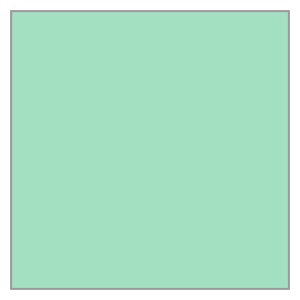

In [15]:
# Return the grid square as a Shapely geometry object for the BNGReference object
bng_ref.bng_to_grid_geom()

### Indexing Shapely Geometries

The `geom_to_bng` and `geom_to_bng_intersection` functions enable the indexing of geometries, represented using `Shapely` Geometry objects, into grid squares at a specified resolution. Both functions accept `Shapely` Geometry objects of the following types: `Point`, `LineString`, `Polygon`, `MultiPoint`, `MultiLineString`, `MultiPolygon`, and `GeometryCollection`. The geometry coordinates must be encoded in the [British National Grid (OSGB36) EPSG:27700](https://epsg.io/27700) coordinate reference system.

These functions facilitate grid-based spatial analysis, enabling applications such as statistical aggregation, data visualisation, and data interoperability. The two functions differ in their operation: 

* `geom_to_bng` returns the BNG grid squares intersected by the input geometry.
* `geom_to_bng_intersection` returns the intersections (shared geometries) between the input geometry and the grid square geometries.

See `examples/notebooks/osbng_indexing_polygon_examples.ipynb` for more examples and detail on the operation of the two functions.

##### Point

In [16]:
# Point
# Easting and northing coordinates
x, y = 437293, 115543

# Construct a Shapely Point geometry from easting and northing coordinates
geom = Point(x, y)

# Return the BNGReference object for the geometry at a 5km resolution
geom_to_bng(geom=geom, resolution="5km")

[BNGReference(bng_ref_formatted=SU 3 1 NE, resolution_label=5km)]

In [17]:
# Return the BNGIndexedGeometry object for the geometry at a 5km resolution
# For a Point geometry, the intersection geometry is the same as the original geometry
# The is_core property will always be False for a Point geometry
geom_to_bng_intersection(geom=geom, resolution="5km")

[BNGIndexedGeometry(bng_ref=BNGReference(bng_ref_formatted=SU 3 1 NE, resolution_label=5km), is_core=False, geom=POINT (437293 115543))]

##### LineString

In [ ]:
# LineString
# Create a Shapely LineString geometry from Well Known Text (WKT)
geom = wkt.loads("LINESTRING (436171.8 114893.7, 437861.3 116130.0)")

# Return a list of the BNGReference object(s)
# intersected by the geometry at a 1km resolution
geom_to_bng(geom=geom, resolution="1km")

[BNGReference(bng_ref_formatted=SU 36 15, resolution_label=1km),
 BNGReference(bng_ref_formatted=SU 36 14, resolution_label=1km),
 BNGReference(bng_ref_formatted=SU 37 16, resolution_label=1km),
 BNGReference(bng_ref_formatted=SU 37 15, resolution_label=1km)]

In [19]:
# Return a list of the BNGIndexedGeometry object(s) for the geometry at a 1km resolution
# The is_core property will always be False for a LineString geometry
geom_to_bng_intersection(geom=geom, resolution="1km")

[BNGIndexedGeometry(bng_ref=BNGReference(bng_ref_formatted=SU 36 15, resolution_label=1km), is_core=False, geom=LINESTRING (436317.06720860634 115000, 437000 115499.7394554602)),
 BNGIndexedGeometry(bng_ref=BNGReference(bng_ref_formatted=SU 36 14, resolution_label=1km), is_core=False, geom=LINESTRING (436171.8 114893.7, 436317.06720860634 115000)),
 BNGIndexedGeometry(bng_ref=BNGReference(bng_ref_formatted=SU 37 16, resolution_label=1km), is_core=False, geom=LINESTRING (437683.64490010514 116000, 437861.3 116130)),
 BNGIndexedGeometry(bng_ref=BNGReference(bng_ref_formatted=SU 37 15, resolution_label=1km), is_core=False, geom=LINESTRING (437000 115499.7394554602, 437683.64490010514 116000))]

In [ ]:
def plot_aesthetics(ax: plt.Axes) -> None:
    """Set the aesthetics for the matplotlib axes.

    Sets the axis labels, removes the figure frame,
    rotates x-axis tick labels, and adds whitespace between labels and ticks.

    Args:
        ax (plt.Axes): The matplotlib axes to set aesthetics for.
    """
    # Set axis labels
    ax.set_xlabel("Easting", fontsize=14)
    ax.set_ylabel("Northing", fontsize=14)

    # Remove the figure frame but keep the ticks and tick labels
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Rotate x axis tick labels by 90 degrees anticlockwise
    plt.xticks(rotation=90)

    # Add whitespace between x and y axis labels and tick labels
    ax.xaxis.labelpad = 20
    ax.yaxis.labelpad = 20

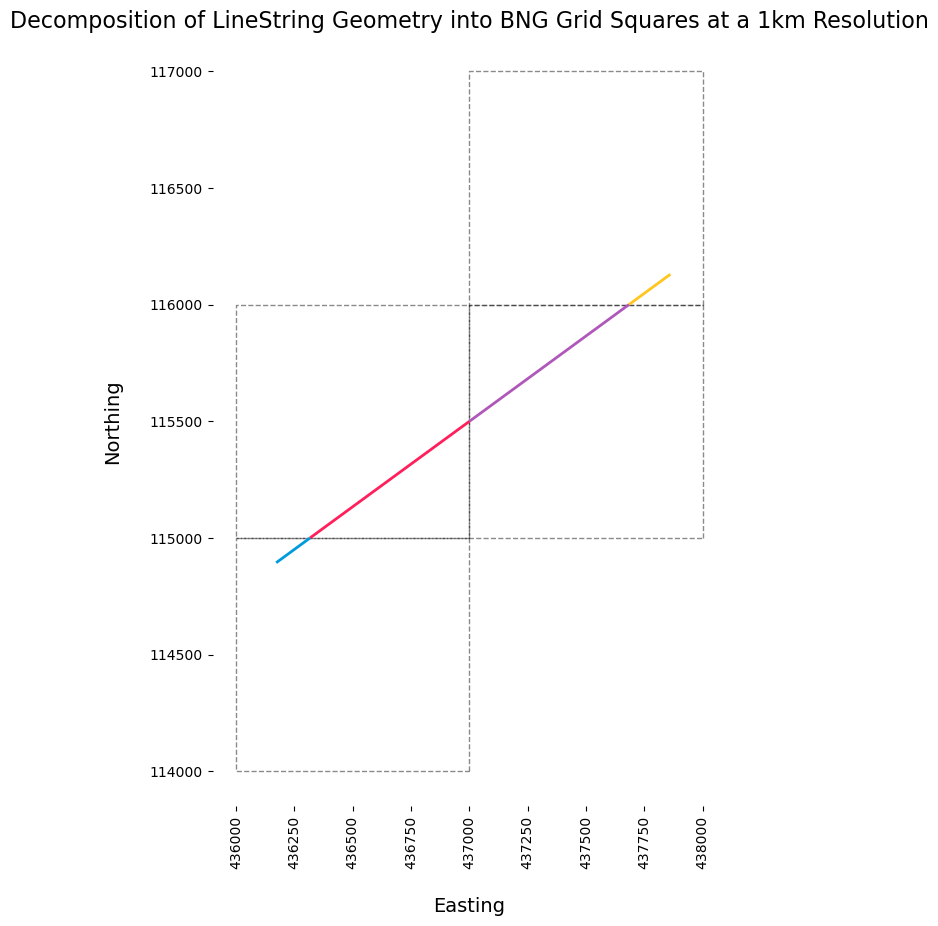

In [ ]:
# Create matplotlib figure and axis
f, ax = plt.subplots(figsize=(10, 10))

# Return a list of the BNGIndexedGeometry objects for the geometry at a 1km resolution
bng_idx_geoms = geom_to_bng_intersection(geom=geom, resolution="1km")

# Extract bng_ref and geom from each BNGIndexedGeometry object
bng_refs = [bng_idx_geom.bng_ref for bng_idx_geom in bng_idx_geoms]
geoms = [bng_idx_geom.geom for bng_idx_geom in bng_idx_geoms]

# Categorical colours
colours = ["#FF1F5B", "#009ADE", "#FFC61E", "#AF58BA"]

# Plot geometries representing the intersection between the geometry
# and the BNG grid squares
gpd.GeoSeries(geoms, crs=27700).plot(
    ax=ax, color=colours, edgecolor="#fff", linewidth=2
)
# Plot intersected BNGReference grid squares for context
gpd.GeoSeries([bng_ref.bng_to_grid_geom() for bng_ref in bng_refs], crs=27700).plot(
    ax=ax, color="none", edgecolor="#00000075", linewidth=1, linestyle="--"
)

# Set the title
ax.set_title(
    "Decomposition of LineString Geometry into BNG Grid Squares at a 1km Resolution",
    fontsize=16,
)
# Set the aesthetics for the matplotlib axes
plot_aesthetics(ax)

##### Polygon

In [ ]:
# Polygon
# Create a Shapely Polygon geometry from Well Known Text (WKT)
geom = wkt.loads(
    "POLYGON ((436661.45305455 115784.01571607, 437629.10896848 116112.11767069, "
    "438229.486575 115953.45344189, 437990.51082297 114935.84767816, "
    "436630.11197232 115085.69722758, 436661.45305455 115784.01571607))"
)

# Return a list of the BNGReference objects
# intersected by the geometry at a 500m resolution
geom_to_bng(geom=geom, resolution=500)

[BNGReference(bng_ref_formatted=SU 37 14 NE, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 37 16 SW, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 37 16 SE, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 37 15 NW, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 37 15 NE, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 38 14 NW, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 38 16 SW, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 36 15 SE, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 37 15 SW, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 37 15 SE, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 38 15 SW, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 36 15 NE, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 38 15 NW, resolution_label=500m),
 BNGReference(bng_ref_formatted=SU 37 14 NW, resolution_label=500m)]

In [23]:
# Return a list of the BNGIndexedGeometry objects for the geometry at a 500m resolution
geom_to_bng_intersection(geom=geom, resolution=500)

[BNGIndexedGeometry(bng_ref=BNGReference(bng_ref_formatted=SU 37 15 NE, resolution_label=500m), is_core=True, geom=POLYGON ((438000 115500, 438000 116000, 437500 116000, 437500 115500, 438000 115500))),
 BNGIndexedGeometry(bng_ref=BNGReference(bng_ref_formatted=SU 37 15 SE, resolution_label=500m), is_core=True, geom=POLYGON ((438000 115000, 438000 115500, 437500 115500, 437500 115000, 438000 115000))),
 BNGIndexedGeometry(bng_ref=BNGReference(bng_ref_formatted=SU 37 14 NE, resolution_label=500m), is_core=False, geom=POLYGON ((437990.51082297 114935.84767816, 437500 114989.87802798908, 437500 115000, 438000 115000, 438000 114976.25446067557, 437990.51082297 114935.84767816))),
 BNGIndexedGeometry(bng_ref=BNGReference(bng_ref_formatted=SU 37 16 SW, resolution_label=500m), is_core=False, geom=POLYGON ((437500 116068.34084433317, 437500 116000, 437298.445509846 116000, 437500 116068.34084433317))),
 BNGIndexedGeometry(bng_ref=BNGReference(bng_ref_formatted=SU 37 16 SE, resolution_label=500

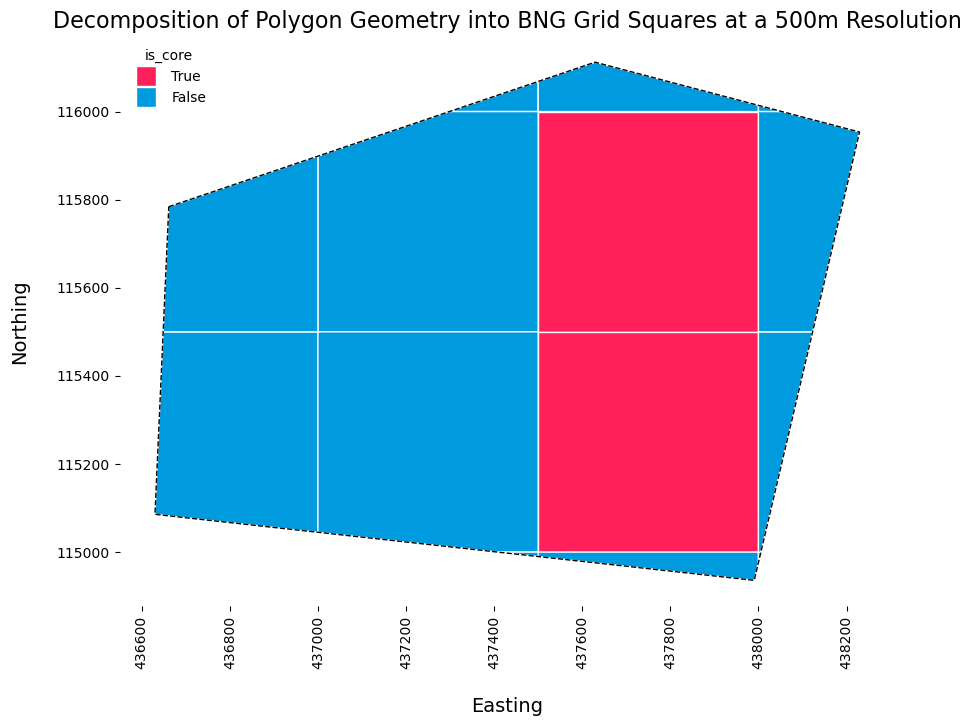

In [ ]:
# Create matplotlib figure and axis
f, ax = plt.subplots(figsize=(10, 10))

# Return a list of the BNGIndexedGeometry objects for the geometry at a 500m resolution
bng_idx_geoms = geom_to_bng_intersection(geom=geom, resolution=500)

# Extract geom property from each BNGIndexedGeometry object
# Seperate core and edge geometries based on is_core property
core = [g.geom for g in bng_idx_geoms if g.is_core]
edge = [g.geom for g in bng_idx_geoms if not g.is_core]

# Plot core and edge geometries
gpd.GeoSeries(core, crs=27700).plot(ax=ax, color="#ff1f5b", edgecolor="#fff")
gpd.GeoSeries(edge, crs=27700).plot(ax=ax, color="#009ade", edgecolor="#fff")
# Plot original Polygon geometry boundary for context
gpd.GeoSeries([geom], crs=27700).boundary.plot(
    ax=ax, color="#000", linewidth=1, linestyle="--"
)

# Set the title
ax.set_title(
    "Decomposition of Polygon Geometry into BNG Grid Squares at a 500m Resolution",
    fontsize=16,
)

# Add a categorical legend for is_core property
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="True",
        markerfacecolor="#ff1f5b",
        markersize=14,
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="False",
        markerfacecolor="#009ade",
        markersize=14,
    ),
]
# Add legend to the plot
legend = ax.legend(handles=legend_elements, title="is_core", loc="upper left")
# Remove legend frame
legend.get_frame().set_linewidth(0)

# Set the aesthetics for the matplotlib axes
plot_aesthetics(ax)

## Hierarchy

* `osbng` provides functionality to navigate the hierarchical structure of the BNG index system.
 * This `osbng.hierarchy` module allows for the traversal of this hierarchy by providing methods to return the parent and children of `BNGReference` objects at specified resolutions.

Parent and child definitions:

* **Parent**: The parent of a `BNGReference` object is the grid square at the next higher (coarser) resolution level that contains the current reference. For example, the parent of a 1km grid square reference would be the 5km grid square that contains it.
* **Children**: The children of a `BNGReference` object are the grid squares at the next lower (finer) resolution level that are contained within the current reference. For example, the children of a 10km grid square reference would be the 5km grid squares that it contains.

* While parent and child derivation defaults to the next higher and lower resolution, **any supported resolution in the hierarchy can be specified**.

In [25]:
# Convert a BNG reference string into a BNGReference object
bng_ref = BNGReference(bng_ref_string="SU 372 155")

# The resolution of the BNGReference object as a descriptive label
bng_ref.resolution_label

'100m'

In [26]:
# Return the parent BNGReference object at the next higher resolution
bng_ref.bng_to_parent()

BNGReference(bng_ref_formatted=SU 37 15 NW, resolution_label=500m)

In [27]:
# Return the parent BNGReference object at a custom higher resolution
bng_ref.bng_to_parent(resolution="50km")

BNGReference(bng_ref_formatted=SU SW, resolution_label=50km)

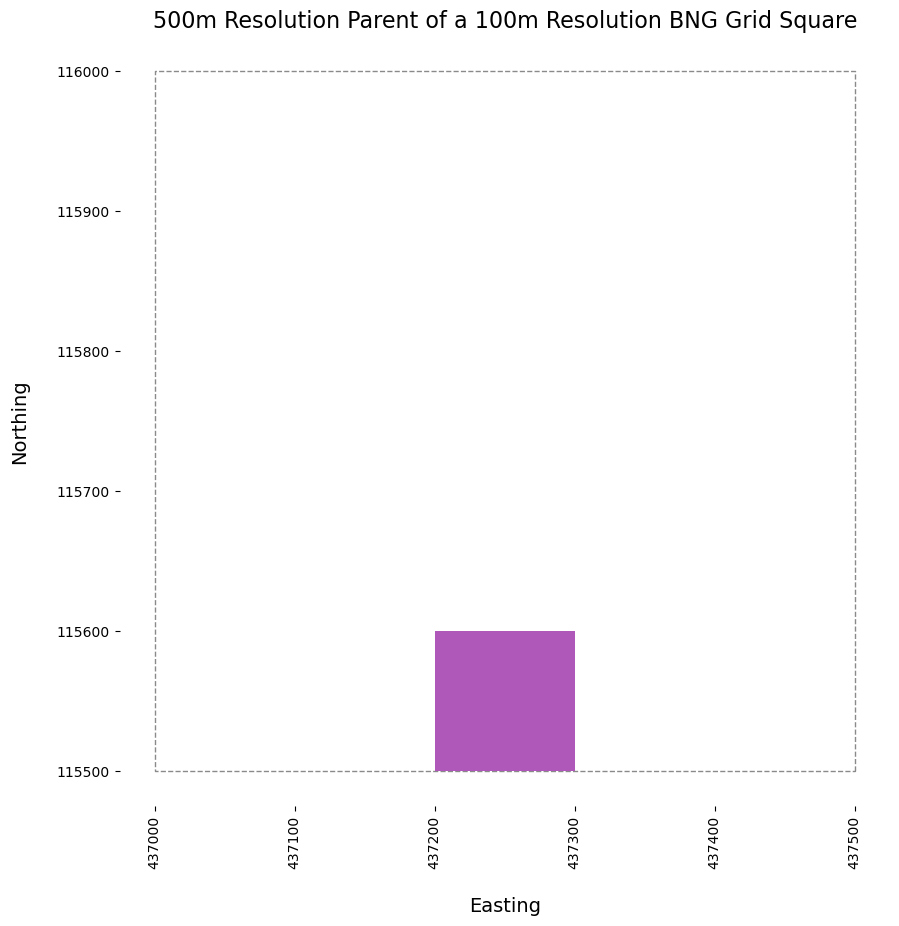

In [ ]:
# Create matplotlib figure and axis
f, ax = plt.subplots(figsize=(10, 10))

# Return the parent BNGReference object
bng_ref_parent = bng_ref.bng_to_parent()

# Plot the parent BNGReference grid square
gpd.GeoSeries([bng_ref_parent.bng_to_grid_geom()], crs=27700).plot(
    ax=ax, color="none", edgecolor="#00000075", linewidth=1, linestyle="--"
)
# Plot the original BNGReference grid square
gpd.GeoSeries([bng_ref.bng_to_grid_geom()], crs=27700).plot(
    ax=ax, color="#AF58BA", edgecolor="none", linewidth=1, linestyle="--"
)

# Set the title
ax.set_title("500m Resolution Parent of a 100m Resolution BNG Grid Square", fontsize=16)

# Set the aesthetics for the matplotlib axes
plot_aesthetics(ax)

In [29]:
# Return the children of the BNGReference object at the next lower resolution
bng_ref.bng_to_children()

[BNGReference(bng_ref_formatted=SU 372 155 SW, resolution_label=50m),
 BNGReference(bng_ref_formatted=SU 372 155 SE, resolution_label=50m),
 BNGReference(bng_ref_formatted=SU 372 155 NW, resolution_label=50m),
 BNGReference(bng_ref_formatted=SU 372 155 NE, resolution_label=50m)]

In [30]:
# Return the children of the BNGReference object at a custom lower resolution
bng_ref.bng_to_children(resolution="10m")

[BNGReference(bng_ref_formatted=SU 3720 1550, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3721 1550, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3722 1550, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3723 1550, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3724 1550, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3725 1550, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3726 1550, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3727 1550, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3728 1550, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3729 1550, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3720 1551, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3721 1551, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3722 1551, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU 3723 1551, resolution_label=10m),
 BNGReference(bng_ref_formatted=SU

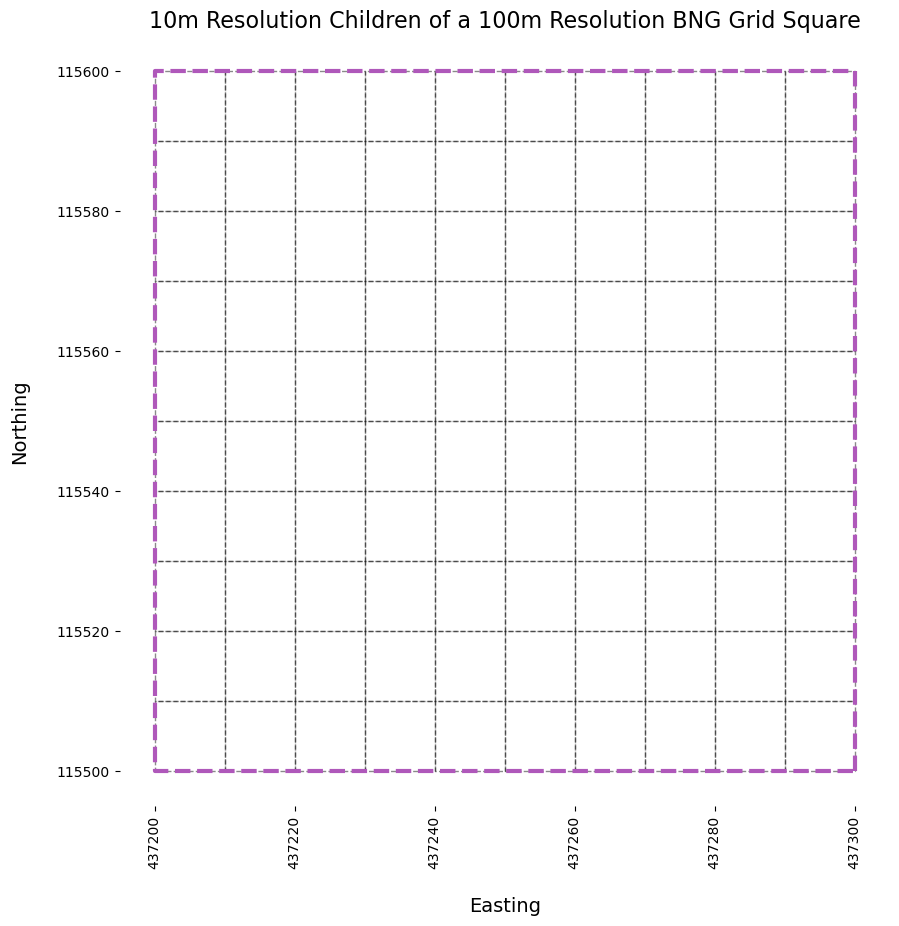

In [ ]:
# Create matplotlib figure and axis
f, ax = plt.subplots(figsize=(10, 10))

# Return the BNGReference object for the children at a 10m resolution
bng_refs_children = bng_ref.bng_to_children(resolution="10m")

# Plot the BNGReference grid squares for each child
gpd.GeoSeries(
    [bng_ref.bng_to_grid_geom() for bng_ref in bng_refs_children], crs=27700
).plot(ax=ax, color="none", edgecolor="#00000075", linewidth=1, linestyle="--")
# Plot the original BNGReference grid square
gpd.GeoSeries([bng_ref.bng_to_grid_geom()], crs=27700).plot(
    ax=ax, color="none", edgecolor="#AF58BA", linewidth=3, linestyle="--"
)

# Set the title
ax.set_title(
    "10m Resolution Children of a 100m Resolution BNG Grid Square", fontsize=16
)

# Set the aesthetics for the matplotlib axes
plot_aesthetics(ax)

## Traversal

* The `osbng.traversal` module provides functionality for traversing and calculating distances within the BNG index system. It supports spatial analyses such as distance-constrained nearest neighbour searches and 'distance within' queries by offering:

    * Generation of k-discs and k-rings around a given grid square.
    * Identification of neighbouring grid squares and checking adjacency.
    * Calculating the distance between grid square centroids.
    * Retrieving all grid squares within a specified absolute distance.

In [ ]:
# Convert a BNG reference string into a BNGReference object
bng_ref = BNGReference(bng_ref_string="SU 372 155")

# Return a list of BNGReference objects representing a filled disc around the
# BNGReference object up to a grid distance k,
# including the given central BNGReference object
bng_ref.bng_kdisc(k=2)

[BNGReference(bng_ref_formatted=SU 370 157, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 371 157, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 372 157, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 373 157, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 374 157, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 370 156, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 371 156, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 372 156, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 373 156, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 374 156, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 370 155, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 371 155, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 372 155, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 373 155, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 374 155, reso

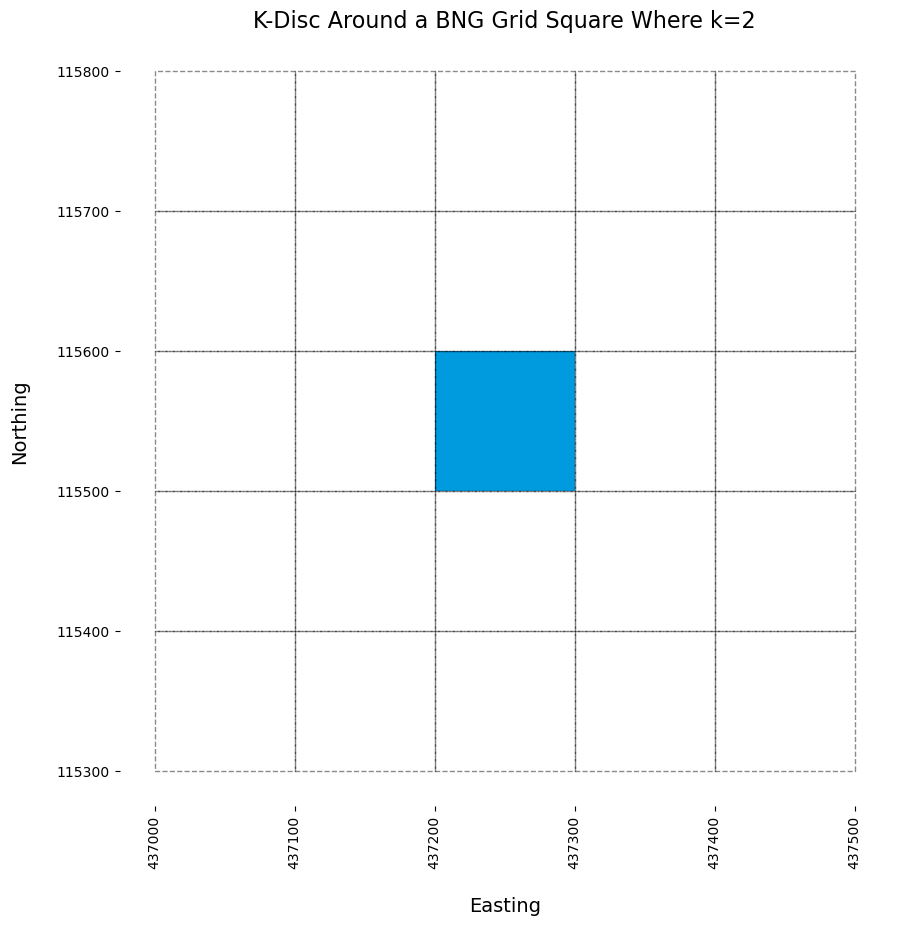

In [ ]:
# Create matplotlib figure and axis
f, ax = plt.subplots(figsize=(10, 10))

# Return a k-disc of the BNGReference object at a grid distance of k=2
bng_ref_kdisc = bng_ref.bng_kdisc(k=2)

# Plot the original BNGReference grid square
gpd.GeoSeries([bng_ref.bng_to_grid_geom()], crs=27700).plot(
    ax=ax, color="#009ade", linewidth=2
)
# Plot the BNGReference grid squares in the k-disc
gpd.GeoSeries(
    [bng_ref.bng_to_grid_geom() for bng_ref in bng_ref_kdisc], crs=27700
).plot(ax=ax, color="none", edgecolor="#00000075", linewidth=1, linestyle="--")

# Set the title
ax.set_title("K-Disc Around a BNG Grid Square Where k=2", fontsize=16)
# Set the aesthetics for the matplotlib axes
plot_aesthetics(ax)

In [ ]:
# Return a list of BNG reference objects representing a epresenting a hollow ring
# around around the BNGReference object at a grid distance k
bng_ref.bng_kring(k=1)

[BNGReference(bng_ref_formatted=SU 371 156, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 372 156, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 373 156, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 371 155, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 373 155, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 371 154, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 372 154, resolution_label=100m),
 BNGReference(bng_ref_formatted=SU 373 154, resolution_label=100m)]

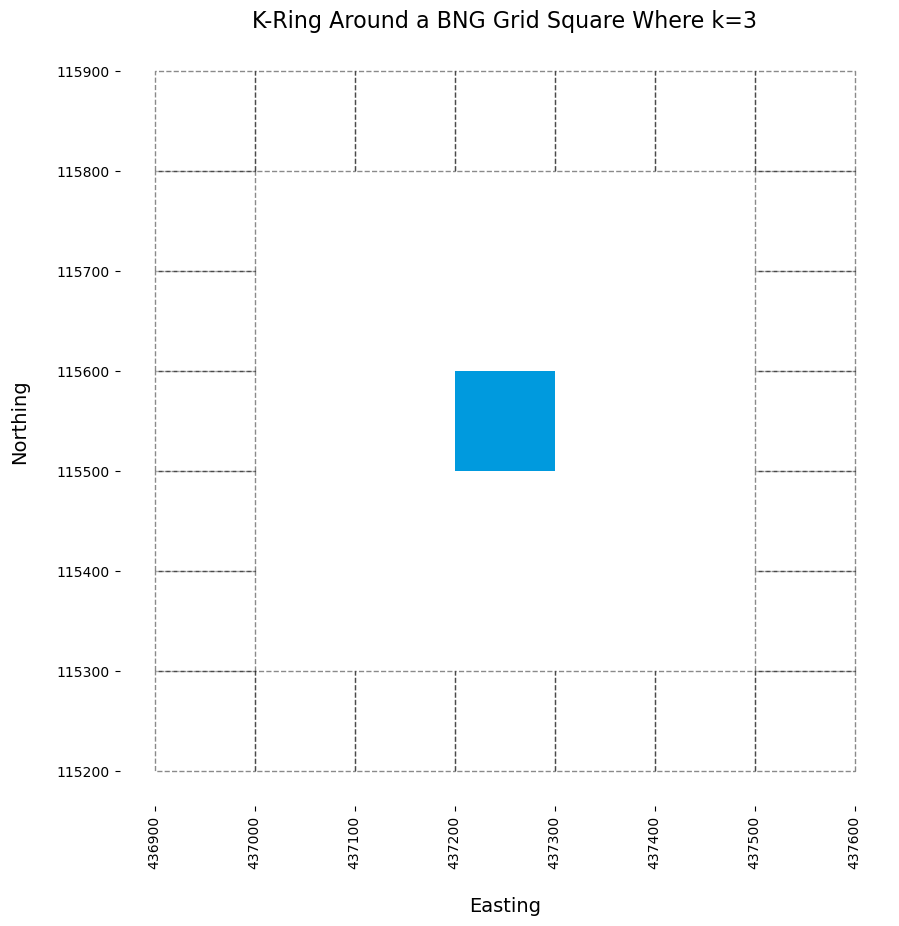

In [ ]:
# Create matplotlib figure and axis
f, ax = plt.subplots(figsize=(10, 10))

# Return a k-ring of the BNGReference object at a grid distance of k=3
bng_ref_kring = bng_ref.bng_kring(k=3)

# Plot the original BNGReference grid square
gpd.GeoSeries([bng_ref.bng_to_grid_geom()], crs=27700).plot(
    ax=ax, color="#009ade", linewidth=2
)
# Plot the BNGReference grid squares in the k-ring
gpd.GeoSeries(
    [bng_ref.bng_to_grid_geom() for bng_ref in bng_ref_kring], crs=27700
).plot(ax=ax, color="none", edgecolor="#00000075", linewidth=1, linestyle="--")

# Set the title
ax.set_title("K-Ring Around a BNG Grid Square Where k=3", fontsize=16)
# Set the aesthetics for the matplotlib axes
plot_aesthetics(ax)

In [36]:
# Convert BNG reference strings into BNGReference objects
bng_ref1 = BNGReference(bng_ref_string="SU 372 155")
bng_ref2 = BNGReference(bng_ref_string="SU 371 155")

# Check if the two BNGReference objects are neighbours
bng_ref1.bng_is_neighbour(bng_ref2=bng_ref2)

True

In [ ]:
# Convert BNG reference strings into BNGReference objects
bng_ref1 = BNGReference(bng_ref_string="SX")
bng_ref2 = BNGReference(bng_ref_string="SU 1 2")

# Return the distance between two BNGReference objects in metres
# The default distance is calculated as the Euclidean distance
# between the centroids of the grid squares
bng_ref1.bng_distance(bng_ref2=bng_ref2)

181245.68960391858

In [38]:
# Return the distance between two BNGReference objects in metres
# edge_to_edge=True calculates the distance between the edges of the grid squares
bng_ref1.bng_distance(bng_ref2=bng_ref2, edge_to_edge=True)

111803.39887498948

In [ ]:
# Convert BNG reference stringsinto a BNGReference object
bng_ref = BNGReference(bng_ref_string="ST 3 8")

# Return all BNGReference objects within a given distance d
# of the input BNGReference object
bng_ref.bng_dwithin(d=1000)

[BNGReference(bng_ref_formatted=ST 2 9, resolution_label=10km),
 BNGReference(bng_ref_formatted=ST 3 9, resolution_label=10km),
 BNGReference(bng_ref_formatted=ST 4 9, resolution_label=10km),
 BNGReference(bng_ref_formatted=ST 2 8, resolution_label=10km),
 BNGReference(bng_ref_formatted=ST 3 8, resolution_label=10km),
 BNGReference(bng_ref_formatted=ST 4 8, resolution_label=10km),
 BNGReference(bng_ref_formatted=ST 2 7, resolution_label=10km),
 BNGReference(bng_ref_formatted=ST 3 7, resolution_label=10km),
 BNGReference(bng_ref_formatted=ST 4 7, resolution_label=10km)]

## Grids

* The `osbng.grids` module provides functionality to generate BNG grid square data within specified bounds. This notebook provides examples of creating data at a range of resolutions and accross custom bounds.
* Grid square data covering the BNG index system bounds is provided with the osbng package as iterators at 100km, 50km, 10km, 5km and 1km resolutions.
* See `bng_grid_<resolution>` in `osbng.grids` module.
* For BNG grid dataset covering the index system bounds at a range of resolutions in GeoPackage (GPKG) and GeoParquet formats see the [`osbng-grids`](https://github.com/OrdnanceSurvey/osbng-grids/) GitHub repo.
* The `bbox_to_bng_iterfeatures` function returns an iterator of `BNGReference` objects represented using a GeoJSON-like mapping within specified bounds at a specified resolution. This function can be used to generate BNG grid data at different resolutions over custom bounds.

In [ ]:
# Create a GeoPandas GeoDataFrame from the 100km resolution packaged iterator
# of BNGReference object Features
# Set the coordinate reference system to British National Grid (EPSG: 27700)
# https://epsg.io/27700
gdf = gpd.GeoDataFrame.from_features(bng_grid_100km, crs=27700)

gdf.head()

,geometry,bng_ref
0,"POLYGON ((100000 0, 100000 100000, 0 100000, 0...",SV
1,"POLYGON ((200000 0, 200000 100000, 100000 1000...",SW
2,"POLYGON ((300000 0, 300000 100000, 200000 1000...",SX
3,"POLYGON ((400000 0, 400000 100000, 300000 1000...",SY
4,"POLYGON ((500000 0, 500000 100000, 400000 1000...",SZ


In [41]:
# Custom bounding box coordinates
# (x_min, y_min, x_max, y_max)
bbox = (529476, 179654, 532170, 181116)

# Generate BNGReference object Features covering the custom bounds at 100m resolution
# Create GeoPandas GeoDataFrame from the iterator of Features
gdf = gpd.GeoDataFrame.from_features(
    bbox_to_bng_iterfeatures(*bbox, resolution="100m"), crs=27700
)

gdf.head()

,geometry,bng_ref
0,"POLYGON ((529500 179600, 529500 179700, 529400...",TQ294796
1,"POLYGON ((529600 179600, 529600 179700, 529500...",TQ295796
2,"POLYGON ((529700 179600, 529700 179700, 529600...",TQ296796
3,"POLYGON ((529800 179600, 529800 179700, 529700...",TQ297796
4,"POLYGON ((529900 179600, 529900 179700, 529800...",TQ298796
